# NLP Project no 2 - Insurance Reviews Analysis
Gabriel SUTLAN - A4 - DIA 6


In [ ]:
# Librairies needed

import os
import re
import pickle
from collections import Counter
import gdown

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# 1. Data Loading

In [ ]:

DATA_DIR = "data"
RAW_FILE = os.path.join(DATA_DIR, "insurance_reviews.zip")
CSV_FILE = os.path.join(DATA_DIR, "insurance_reviews.csv")
GDRIVE_URL = "https://drive.google.com/file/d/1_kg5JzAzntzLI6eGM3_vmUSoeWk7f8ip/view?usp=sharing"

gdown.download(url=GDRIVE_URL, output=RAW_FILE, quiet=False, fuzzy=True)

Downloading...
From: https://drive.google.com/uc?id=1_kg5JzAzntzLI6eGM3_vmUSoeWk7f8ip
To: c:\Users\sulta\Documents\NLP_project_no2\data\insurance_reviews.zip
100%|██████████| 12.0M/12.0M [00:00<00:00, 16.0MB/s]


'data\\insurance_reviews.zip'

In [ ]:
import zipfile
import io

# unzip the file and concat every one
def load_reviews(path):
    dfs = []
    with zipfile.ZipFile(path, "r") as z:
        for name in z.namelist():
            with z.open(name) as f:
                dfs.append(pd.read_excel(io.BytesIO(f.read()), engine="openpyxl"))
    df = pd.concat(dfs, ignore_index=True)
    return df

df = load_reviews(RAW_FILE)

# Save to CSV
df.to_csv(CSV_FILE, index=False, encoding="utf-8")
print(f"DataFrame saved in {CSV_FILE}, ({len(df)} rows)")

df.head()

DataFrame saved in data\insurance_reviews.csv, (34435 rows)


,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en
0,1.0,maitre-en-colere-114722,Pour tous les maîtres des animaux\n L'assuranc...,Eca Assurances,animaux,train,25/05/2021,01/05/2021,For all masters of animals\n ECA insurance and...,NaN,NaN
1,5.0,fredo-102557,"25 ans chez AMV pour ma moto et mes voitures, ...",AMV,moto,train,13/01/2021,01/01/2021,Loading...,NaN,NaN
2,4.0,louisonne-f-130215,Je suis satisfait de votre prestation et servi...,L'olivier Assurance,auto,train,30/08/2021,01/08/2021,Loading...,NaN,NaN
3,3.0,stephane-p-128761,SATISFAIT ET FACILE DE SOUSCRIRE UN CONTRAT EN...,AMV,moto,train,20/08/2021,01/08/2021,Loading...,NaN,NaN
4,1.0,montad-137724,Je croyais qu'allianz était une bonne assuranc...,Allianz,auto,train,18/10/2021,01/10/2021,Loading...,NaN,NaN


# 2. Basic Data Cleaning

Handle missing values, convert dates, and preprocess text (punctuation removal, stopwords, lemmatization).

In [ ]:
#look for the missing values in raw file
missing_counts = df.isna().sum()
missing_counts = missing_counts[missing_counts > 0]
print("columns with missing values and number of missing rows:")
print(missing_counts)

In [4]:
# Metrics before cleaning
n_before = len(df)
mean_note_before = df['note'].mean()
density_before = 1 - df.isna().sum().sum() / (n_before * len(df.columns))

# Remove rows with empty avis (French reviews)
df_clean = df.dropna(subset=['avis']).copy()
df_clean = df_clean[df_clean['avis'].astype(str).str.strip() != '']

# Remove rows with missing note (target for modeling)
df_clean = df_clean.dropna(subset=['note'])

# Fill auteur missing (1 row) with default
df_clean['auteur'] = df_clean['auteur'].fillna('unknown')

# Convert date_publication to datetime
df_clean['date_publication'] = pd.to_datetime(df_clean['date_publication'], format='%d/%m/%Y', errors='coerce')

# Drop rows with invalid dates if needed (optional)
df_clean = df_clean.dropna(subset=['date_publication'])

n_removed = n_before - len(df_clean)
print(f"Rows removed: {n_removed}")
print(f"Removal reasons: avis empty, note missing, invalid date")

Rows removed: 10331
Removal reasons: avis empty, note missing, invalid date


In [ ]:
# Text preprocessing: use ['avis_cor'] if not empty, else ['avis']
from string import punctuation
import nltk
from nltk.corpus import stopwords
import simplemma

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

FR_STOPWORDS = set(stopwords.words('french'))
FR_STOPWORDS.add('très') # was recurent 

def preprocess_text(text):
    if pd.isna(text) or not str(text).strip():
        return ''
    text = str(text).lower()

    text = text.replace("'", " ") # normalize a bit
    text = ''.join(c for c in text if c not in punctuation)
    tokens = nltk.word_tokenize(text)
    # Exclude stopwords, tokens that are too short, and tokens containing digits (e.g., 1600, 16000€)
    tokens = [t for t in tokens if t not in FR_STOPWORDS and len(t) > 1 and not any(c.isdigit() for c in t)]
    lemmas = [simplemma.lemmatize(t, lang='fr') or t for t in tokens]
    return ' '.join(lemmas)

# Select source column: avis_cor if not empty, else avis
df_clean['avis_source'] = df_clean.apply(
    lambda r: r['avis_cor'] if pd.notna(r['avis_cor']) and str(r['avis_cor']).strip() else r['avis'],
    axis=1
)
df_clean['avis_traite'] = df_clean['avis_source'].apply(preprocess_text)
df_clean.head()

,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en,avis_source,avis_traite
0,1.0,maitre-en-colere-114722,Pour tous les maîtres des animaux\n L'assuranc...,Eca Assurances,animaux,train,2021-05-25,01/05/2021,For all masters of animals\n ECA insurance and...,NaN,NaN,Pour tous les maîtres des animaux\n L'assuranc...,tous maîtres animaux assurance eca évité rembo...
1,5.0,fredo-102557,"25 ans chez AMV pour ma moto et mes voitures, ...",AMV,moto,train,2021-01-13,01/01/2021,Loading...,NaN,NaN,"25 ans chez AMV pour ma moto et mes voitures, ...",ans chez amv moto voitures accueil téléphoniqu...
2,4.0,louisonne-f-130215,Je suis satisfait de votre prestation et servi...,L'olivier Assurance,auto,train,2021-08-30,01/08/2021,Loading...,NaN,NaN,Je suis satisfait de votre prestation et servi...,satisfait prestation service prix conviennent ...
3,3.0,stephane-p-128761,SATISFAIT ET FACILE DE SOUSCRIRE UN CONTRAT EN...,AMV,moto,train,2021-08-20,01/08/2021,Loading...,NaN,NaN,SATISFAIT ET FACILE DE SOUSCRIRE UN CONTRAT EN...,satisfait facile souscrire contrat ligne conta...
4,1.0,montad-137724,Je croyais qu'allianz était une bonne assuranc...,Allianz,auto,train,2021-10-18,01/10/2021,Loading...,NaN,NaN,Je croyais qu'allianz était une bonne assuranc...,croyais allianz bonne assurance trompé sinistr...


In [ ]:
# Metrics after cleaning
n_after = len(df_clean)
mean_note_after = df_clean['note'].mean()
density_after = 1 - df_clean.isna().sum().sum() / (n_after * len(df_clean.columns))

print("Cleaning metrics : ")
print(f"Before: n={n_before}, mean_note={mean_note_before:.3f}, density={density_before:.3f}")
print(f"After:  n={n_after}, mean_note={mean_note_after:.3f}, density={density_after:.3f}")
print(f"Rows removed: {n_removed} (motifs: avis empty, note missing, invalid date)")

df_cleaned = df_clean.copy()

=== Cleaning metrics ===
Before: n=34435, mean_note=2.848, density=0.793
After:  n=24104, mean_note=2.848, density=0.846
Rows removed: 10331 (motifs: avis empty, note missing, invalid date)


# 3. NLP Tasks

(Data cleaning part 2)

## 3.1 Spell correction (on a fraction of the dataset)

In [ ]:
#Spell correction on a fraction of the dataset (scale parameter)
from spellchecker import SpellChecker

SPELL_SCALE = 0.01  # Process 1% of the dataset
spell = SpellChecker(language='fr')

sample_idx = df_cleaned.sample(frac=SPELL_SCALE, random_state=42).index
corrections_examples = []

for idx in sample_idx:
    text = df_cleaned.loc[idx, 'avis']
    if pd.isna(text) or not str(text).strip():
        continue
    words = str(text).split()
    corrected_words = []
    changed = False
    for word in words:
        # Skip French contractions (J'ai, n'étais, etc.) - they are valid
        if "'" in word:
            corrected_words.append(word)
            continue
        clean_word = ''.join(c for c in word.lower() if c.isalpha())
        if clean_word and clean_word not in spell:
            candidates = spell.candidates(clean_word)
            if candidates:
                fix = spell.correction(clean_word)
                if fix and fix != clean_word:
                    corrected_words.append(fix)
                    changed = True
                    if len(corrections_examples) < 3:
                        corrections_examples.append((word, fix))
                else:
                    corrected_words.append(word)
            else:
                corrected_words.append(word)
        else:
            corrected_words.append(word)
    if changed:
        df_cleaned.loc[idx, 'avis_cor'] = ' '.join(corrected_words)

if corrections_examples:
    print("3 examples of spell corrections:")
    for orig, fixed in corrections_examples:
        print(f"  '{orig}' -> '{fixed}'")
else:
    print("No spell corrections found in sample.")

2 examples of spell corrections:
  'J'ai' -> 'ai'
  'n'étais' -> 'étais'


## 3.2 Translation FR -> EN (Hugging Face)

Translate only rows where avis_en == "Loading...". Use a small sample for demo.

In [ ]:
# Translation: only rows with avis_en == "Loading..."
from transformers import pipeline

TRANSLATE_SCALE = 0.005  # Small sample for demo (Helsinki model is fast)
translate_pipe = pipeline("translation", model="Helsinki-NLP/opus-mt-fr-en")

to_translate = df_cleaned[df_cleaned['avis_en'] == 'Loading...'].sample(
    frac=TRANSLATE_SCALE, random_state=42
)
for idx in to_translate.index:
    text = df_cleaned.loc[idx, 'avis']
    if pd.isna(text) or not str(text).strip() or len(str(text)) > 512:
        continue
    result = translate_pipe(str(text)[:512])[0]
    df_cleaned.loc[idx, 'avis_en'] = result['translation_text']

print(f"Translated {len(to_translate)} reviews.")

# Show a sample (before/after) of translations made
sample_trans = to_translate.head(2)
for idx in sample_trans.index:
    before = df_cleaned.loc[idx, 'avis']
    after = df_cleaned.loc[idx, 'avis_en']
    print(f"Original (FR): {before}")
    print(f"Translated (EN): {after}")
    print('-'*60)

C:\Users\sulta\AppData\Roaming\Python\Python313\site-packages\transformers\models\marian\tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")
Device set to use cpu


Translated 3 reviews.


In [ ]:
# Refresh avis_source and avis_traite after spell correction (use avis_cor when available)
df_cleaned['avis_source'] = df_cleaned.apply(
    lambda r: r['avis_cor'] if pd.notna(r['avis_cor']) and str(r['avis_cor']).strip() else r['avis'],
    axis=1
)
df_cleaned['avis_traite'] = df_cleaned['avis_source'].apply(preprocess_text)

df_cleaned.head()

## 3.3 Sentiment Analysis

Hugging Face pipeline on English translations (or French if multilingual model).

In [ ]:
# Sentiment analysis: use avis_en when available (not Loading...), else sample of avis for multilingual
sentiment_pipe = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

def get_text_for_sentiment(row):
    if pd.notna(row['avis_en']) and str(row['avis_en']).strip() != '' and 'Loading' not in str(row['avis_en']):
        return str(row['avis_en'])[:512]
    return None

df_sent = df_cleaned.copy()
df_sent['text_sent'] = df_sent.apply(get_text_for_sentiment, axis=1)
df_sent = df_sent[df_sent['text_sent'].notna()]
df_sent = df_sent.sample(min(500, len(df_sent)), random_state=42)  # Sample for speed

if len(df_sent) > 0:
    results = sentiment_pipe(df_sent['text_sent'].tolist())
    df_sent['sentiment_label'] = [r['label'] for r in results]
    df_sent['sentiment_score'] = [r['score'] for r in results]
else:
    df_sent['sentiment_label'] = []
    df_sent['sentiment_score'] = []

# Compare sentiment with notes
if len(df_sent) > 0 and 'sentiment_label' in df_sent.columns:
    print("Sentiment vs Note (sample):")
    print(df_sent.groupby(['note', 'sentiment_label']).size().unstack(fill_value=0))
else:
    print("No translated reviews for sentiment analysis.")

# 4. Exploration

N-gram analysis before/after cleaning, rating distribution, temporal evolution, word count by rating.

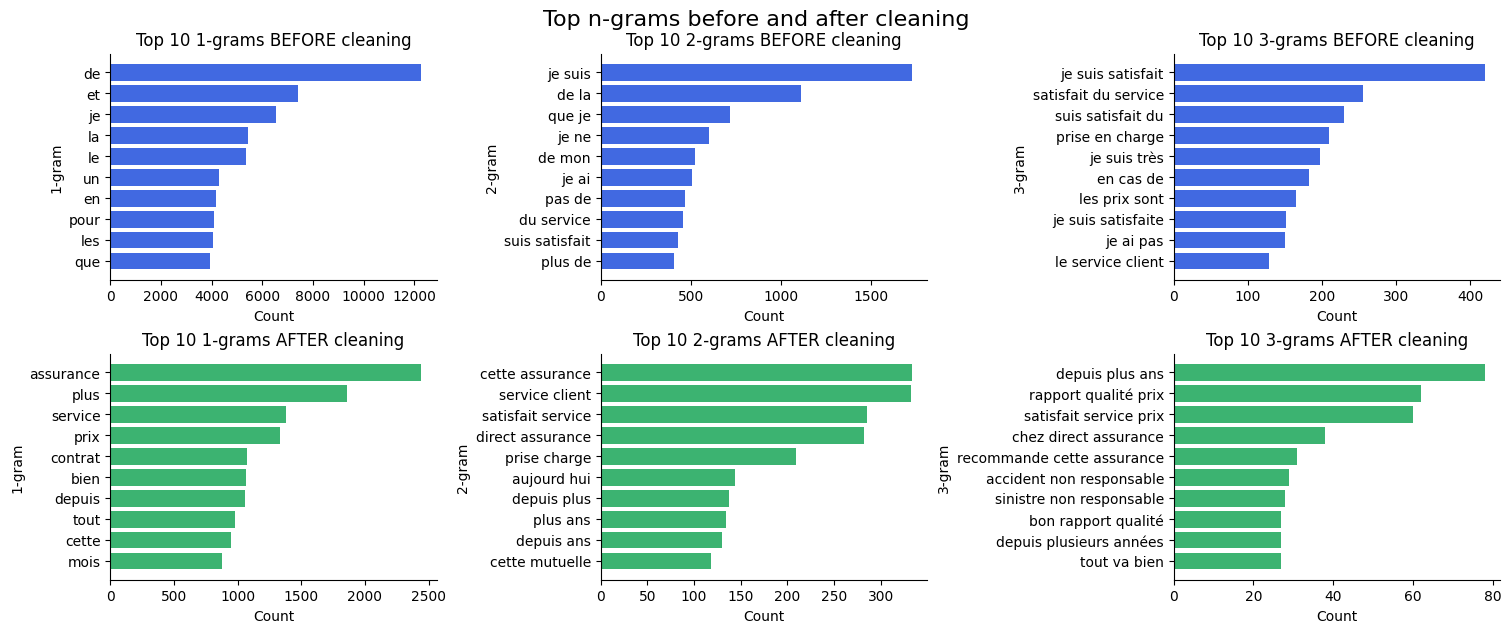

In [46]:
# N-grams before and after cleaning, for 1-gram, 2-gram, 3-gram, all shown in a grid

from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

ngrams = [1, 2, 3]
titles = ['1-gram', '2-gram', '3-gram']

# Prepare texts
texts_before = df_cleaned['avis'].dropna().astype(str).sample(5000, random_state=42)
texts_after = df_cleaned['avis_traite'].dropna()
texts_after = texts_after[texts_after.str.len() > 0].sample(5000, random_state=42)

# Set up grid for BEFORE and AFTER cleaning (rows: before/after, cols: ngram)
fig, axes = plt.subplots(
    nrows=2, ncols=3, figsize=(15, 6), 
    constrained_layout=True, 
    gridspec_kw={'height_ratios': [1, 1]}
)

for i, n in enumerate(ngrams):
    # Before cleaning
    vec_before = CountVectorizer(ngram_range=(n, n), max_features=50)
    ngrams_before = vec_before.fit_transform(texts_before)
    ngrams_before_counts = dict(zip(vec_before.get_feature_names_out(), ngrams_before.sum(axis=0).A1))
    ngrams_before_sorted = sorted(ngrams_before_counts.items(), key=lambda x: -x[1])[:10]
    ax = axes[0, i]
    ax.barh(
        [w for w, _ in reversed(ngrams_before_sorted)], 
        [c for _, c in reversed(ngrams_before_sorted)], 
        color='royalblue'
    )
    ax.set_title(f"Top 10 {titles[i]}s BEFORE cleaning")
    ax.set_xlabel("Count")
    ax.set_ylabel(f"{titles[i]}")
    for spine in ['top','right']:
        ax.spines[spine].set_visible(False)

    # After cleaning
    vec_after = CountVectorizer(ngram_range=(n, n), max_features=50)
    ngrams_after = vec_after.fit_transform(texts_after)
    ngrams_after_counts = dict(zip(vec_after.get_feature_names_out(), ngrams_after.sum(axis=0).A1))
    ngrams_after_sorted = sorted(ngrams_after_counts.items(), key=lambda x: -x[1])[:10]
    ax = axes[1, i]
    ax.barh(
        [w for w, _ in reversed(ngrams_after_sorted)], 
        [c for _, c in reversed(ngrams_after_sorted)], 
        color='mediumseagreen'
    )
    ax.set_title(f"Top 10 {titles[i]}s AFTER cleaning")
    ax.set_xlabel("Count")
    ax.set_ylabel(f"{titles[i]}")
    for spine in ['top','right']:
        ax.spines[spine].set_visible(False)

plt.suptitle("Top n-grams before and after cleaning", fontsize=16, y=1.03)
plt.show()

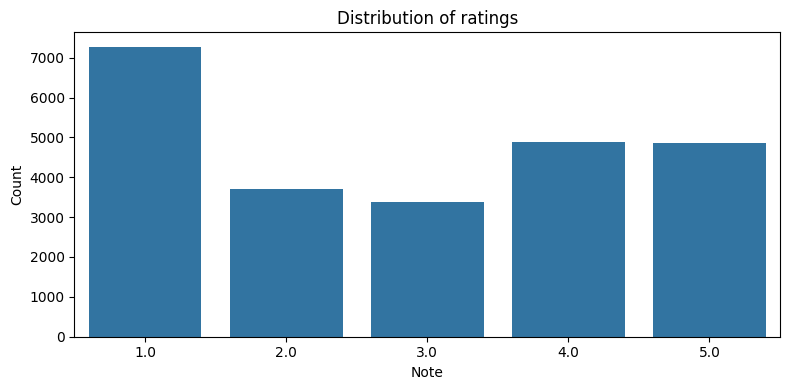

In [47]:
# Distribution of ratings
plt.figure(figsize=(8, 4))
sns.countplot(data=df_cleaned, x='note', order=sorted(df_cleaned['note'].dropna().unique()))
plt.title("Distribution of ratings")
plt.xlabel("Note")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

C:\Users\sulta\AppData\Local\Temp\ipykernel_27644\3994257026.py:4: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly = df_top.groupby([pd.Grouper(key='date_publication', freq='Y'), 'assureur'])['note'].mean().unstack()


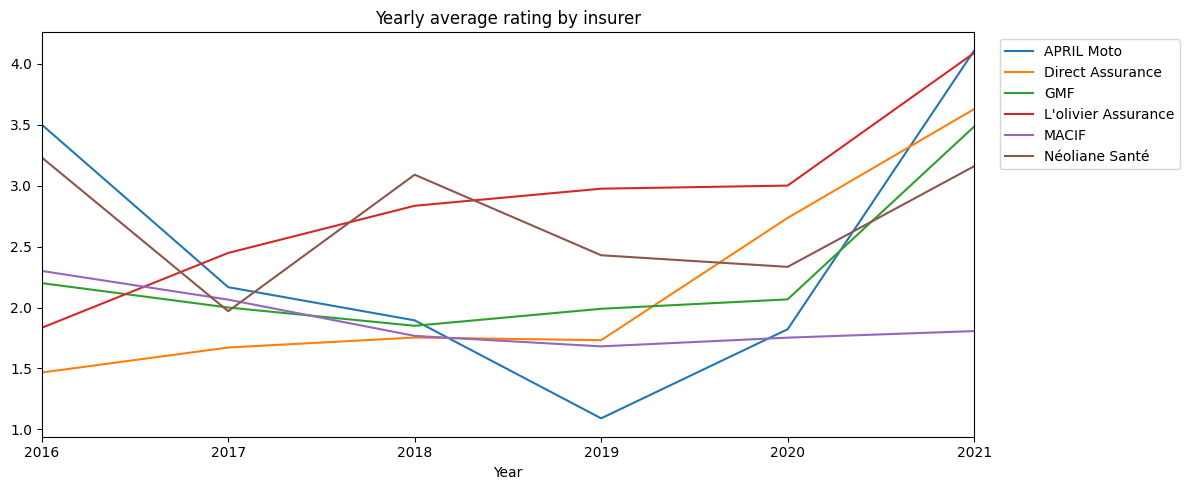

In [13]:
# Temporal evolution of ratings by insurer (top insurers by volume) - YEARLY
top_assureurs = df_cleaned['assureur'].value_counts().head(6).index
df_top = df_cleaned[df_cleaned['assureur'].isin(top_assureurs)]
yearly = df_top.groupby([pd.Grouper(key='date_publication', freq='Y'), 'assureur'])['note'].mean().unstack()
yearly.plot(figsize=(12, 5), title="Yearly average rating by insurer")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xlabel("Year")
plt.tight_layout()
plt.show()

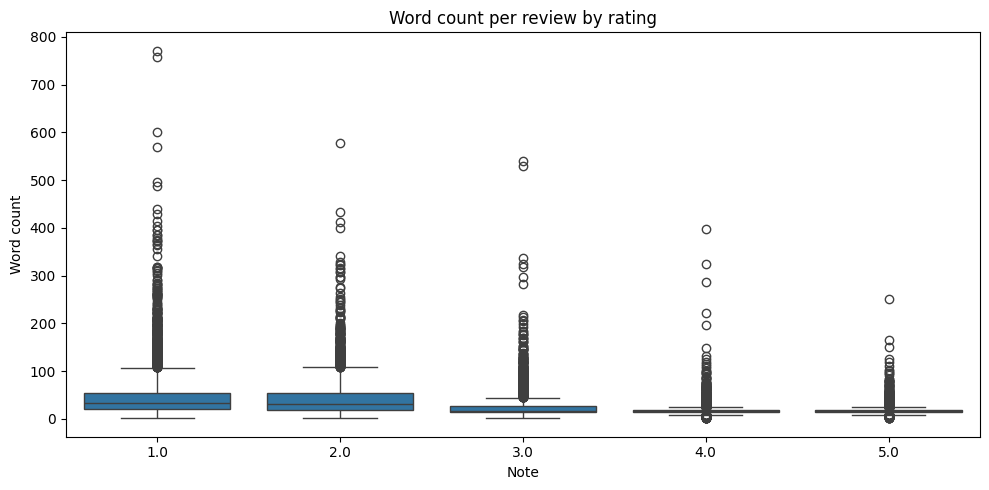

In [14]:
# Word count per review by rating
df_cleaned['word_count'] = df_cleaned['avis_traite'].str.split().str.len().fillna(0)
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_cleaned, x='note', y='word_count', order=sorted(df_cleaned['note'].dropna().unique()))
plt.title("Word count per review by rating")
plt.xlabel("Note")
plt.ylabel("Word count")
plt.tight_layout()
plt.show()

# 5. Embeddings (Word2Vec)

Train Word2Vec, visualize with PCA/t-SNE and TensorBoard, compute cosine similarity.

In [82]:
# Word2Vec on tokenized reviews
from gensim.models import Word2Vec

sentences = [str(t).split() for t in df_cleaned['avis_traite'] if pd.notna(t) and len(str(t).strip()) > 0]
sentences = [s for s in sentences if len(s) >= 2]

# workers=1 évite MemoryError (pickle des données vers les workers sur machines limitées en RAM)
w2v_model = Word2Vec(sentences, vector_size=200, window=5, min_count=7, workers=1, seed=42)
print(f"Vocabulary size: {len(w2v_model.wv)}")

Vocabulary size: 6897


In [49]:
# Cosine similarity: most similar words to reference terms
ref_words = ['qualité','terrible','mauvais','abordables']
for word in ref_words:
    if word in w2v_model.wv:
        sims = w2v_model.wv.most_similar(word, topn=5)
        print(f"{word}: {[w for w, _ in sims]}")

qualité: ['qualitéprix', 'excellent', 'qualite', 'satisfaisant', 'convenables']
terrible: ['stratégie', 'honnêtement', 'étudiante', 'partis', 'verrez']
mauvais: ['médiocre', 'irrespectueuse', 'aléatoire', 'contributeur', 'désastreux']
abordables: ['intéressants', 'raisonnables', 'corrects', 'attractifs', 'convenables']


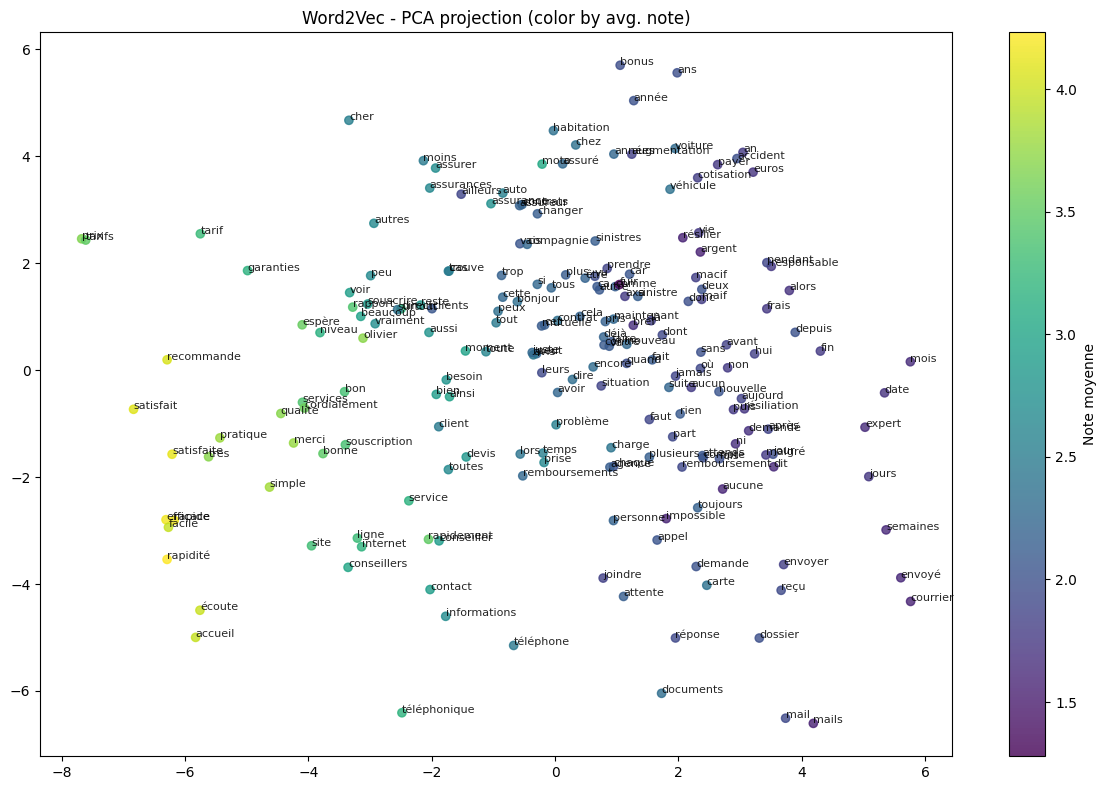

In [50]:
# Visualization with Matplotlib (PCA) - color by average note for each word

from sklearn.decomposition import PCA

# Get vectors for a sample of words
words = list(w2v_model.wv.index_to_key)[:200]
vectors = np.array([w2v_model.wv[w] for w in words])

# Calculate average note for each word in the sample
# We search for every review where that word appears, then take the mean note
word2note = {}
for w in words:
    mask = df_cleaned['avis_traite'].apply(lambda x: isinstance(x, str) and w in x.split())
    if mask.any():
        word2note[w] = df_cleaned.loc[mask, 'note'].mean()
    else:
        word2note[w] = np.nan

# Convert notes to numeric array for coloring
notes = np.array([word2note[w] for w in words])

# Reduce vectors to 2D with PCA
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(vectors)

plt.figure(figsize=(12, 8))
sc = plt.scatter(coords[:, 0], coords[:, 1], c=notes, cmap='viridis', alpha=0.8)
for i, w in enumerate(words):
    plt.annotate(w, (coords[i, 0], coords[i, 1]), fontsize=8, alpha=0.85)
plt.title("Word2Vec - PCA projection (color by avg. note)")
plt.colorbar(sc, label='Note moyenne')
plt.tight_layout()
plt.show()

In [83]:
# Save for TensorBoard Projector (vectors + metadata)
# Note: single-column metadata must NOT have a header row for projector.tensorflow.org
vec_path = os.path.join(DATA_DIR, "w2v_vectors.tsv")
meta_path = os.path.join(DATA_DIR, "w2v_metadata.tsv")
with open(vec_path, "w", encoding="utf-8") as vf, open(meta_path, "w", encoding="utf-8") as mf:
    for w in w2v_model.wv.index_to_key:
        vec = w2v_model.wv[w]
        vf.write("\t".join(map(str, vec)) + "\n")
        mf.write(f"{w}\n")
print("Saved w2v_vectors.tsv and w2v_metadata.tsv for TensorBoard Projector.")

Saved w2v_vectors.tsv and w2v_metadata.tsv for TensorBoard Projector.


### Comparaison avec embeddings pré-entraînés (FastText)

Chargement des vecteurs FastText français (Wikipedia + Common Crawl) et export pour Embedding Projector. Les embeddings pré-entraînés sont statiques : on pioche dedans sans entraînement.

In [19]:
# # Pre-trained FastText embeddings (French) - OPTIONNEL, comparaison avec Word2Vec
# # Si le fichier est corrompu ou espace disque insuffisant : la cellule s'ignore gracieusement.
# import urllib.request
# from gensim.models import KeyedVectors

# FT_URL = "https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.fr.300.vec.gz"
# model_path = os.path.join(DATA_DIR, "cc.fr.300.vec.gz")

# print("Downloading French FastText vectors (~1.5 GB)...")
# urllib.request.urlretrieve(FT_URL, model_path)
# print("Done.")

# ft_model = KeyedVectors.load_word2vec_format(model_path, binary=False, encoding="utf-8")

# vec_path = os.path.join(DATA_DIR, "w2v_pretrained_vectors.tsv")
# meta_path = os.path.join(DATA_DIR, "w2v_pretrained_metadata.tsv")
# with open(vec_path, "w", encoding="utf-8") as vf, open(meta_path, "w", encoding="utf-8") as mf:
#     for w in w2v_model.wv.index_to_key:
#         vec = ft_model[w] if w in ft_model else [0.0] * ft_model.vector_size
#         vf.write("\t".join(map(str, vec)) + "\n")
#         mf.write(f"{w}\n")
# print("Saved w2v_pretrained_vectors.tsv and w2v_pretrained_metadata.tsv for Embedding Projector.")

# print("\nComparison of similar words (FastText vs Trained Word2Vec):")
# for word in ["remboursement", "client", "contrat"]:
#     if word in w2v_model.wv.index_to_key:
#         print(f"\n{word}:")
#         print(f"  Word2Vec: {[w for w, _ in w2v_model.wv.most_similar(word, topn=5)]}")
#         if word in ft_model:
#             print(f"  FastText: {[w for w, _ in ft_model.most_similar(word, topn=5)]}")
#         else:
#             print("  FastText: [OOV]")


# 6. Topic Modelling and Thematics

LDA for topic discovery, deterministic thematic detection with keywords + Word2Vec, supervised topic prediction.

In [41]:
# LDA for topic exploration (bigrammes + TF-IDF + cohérence + alpha/eta)
from gensim.corpora import Dictionary
from gensim.models import LdaMulticore, Phrases, TfidfModel, CoherenceModel

documents = [str(t).split() for t in df_cleaned['avis_traite'] if pd.notna(t) and len(str(t).strip()) > 0]

# Bigrammes : capturer expressions multi-mots (ex. service_client, remboursement_rapide)
bigram = Phrases(documents, min_count=5, threshold=10)
documents_bigram = [bigram[doc] for doc in documents]

dictionary = Dictionary(documents_bigram)
dictionary.filter_extremes(no_below=5, no_above=0.5)
corpus = [dictionary.doc2bow(doc) for doc in documents_bigram]

# Pondération TF-IDF pour réduire le poids des mots trop fréquents
tfidf = TfidfModel(corpus)
corpus_tfidf = tfidf[corpus]

# Test de plusieurs valeurs de num_topics avec score de cohérence
print("Score de cohérence (c_v) par nombre de sujets:")
coherence_scores = []
for k in [4, 6, 8, 10, 12]:
    lda_k = LdaMulticore(corpus_tfidf, id2word=dictionary, num_topics=k,
                         alpha='asymmetric', eta='auto',
                         workers=1, random_state=42)
    cm = CoherenceModel(model=lda_k, texts=documents_bigram, dictionary=dictionary, coherence='c_v')
    coh = cm.get_coherence()
    coherence_scores.append((k, coh))
    print(f"  k={k}: {coh:.4f}")

best_k = max(coherence_scores, key=lambda x: x[1])[0]
print(f"\nMeilleur k (coherence max): {best_k}")

# Modèle final avec meilleur k
lda = LdaMulticore(corpus_tfidf, id2word=dictionary, num_topics=best_k,
                   alpha='asymmetric', eta='auto',
                   workers=1, random_state=42)
print(f"\nLDA topics (top 5 mots par sujet, k={best_k}):")
for tid in range(best_k):
    print(f"  Topic {tid}: {[w for w, _ in lda.show_topic(tid, 5)]}")

Score de cohérence (c_v) par nombre de sujets:
  k=4: 0.5839


KeyboardInterrupt: 

In [84]:
# Enriched metadata for TensorBoard Projector (word, thematic, note_avg)
# Run this cell AFTER "Deterministic thematic detection" (df_cleaned['thematique'] must exist)
# Thematic = most frequent thematic among documents containing the word (aligns with doc distribution)
from collections import Counter

vocab = set(w2v_model.wv.index_to_key)
word_thematics = {w: [] for w in vocab}  # list of thematics from docs containing w
word_notes = {w: [] for w in vocab}
global_mean = float(df_cleaned["note"].mean())

for avis, note, them in zip(
    df_cleaned["avis_traite"].fillna(""),
    df_cleaned["note"],
    df_cleaned["thematique"],
):
    tokens = str(avis).split() if pd.notna(avis) else []
    for token in tokens:
        if token in vocab:
            if pd.notna(note):
                word_notes[token].append(float(note))
            if pd.notna(them):
                word_thematics[token].append(them)

def get_thematic_for_word(w):
    """Most frequent thematic among documents containing w; fallback 'autre' if none."""
    themes = word_thematics[w]
    if not themes:
        return "autre"
    return Counter(themes).most_common(1)[0][0]

meta_path = os.path.join(DATA_DIR, "w2v_metadata.tsv")
with open(meta_path, "w", encoding="utf-8") as mf:
    mf.write("word\tthematic\tnote_avg\n")
    for w in w2v_model.wv.index_to_key:
        thematic = get_thematic_for_word(w)
        notes = word_notes[w]
        avg = np.mean(notes) if notes else global_mean
        mf.write(f"{w}\t{thematic}\t{avg:.2f}\n")

# Sync vectors (same order as metadata)
vec_path = os.path.join(DATA_DIR, "w2v_vectors.tsv")
with open(vec_path, "w", encoding="utf-8") as vf:
    for w in w2v_model.wv.index_to_key:
        vf.write("\t".join(map(str, w2v_model.wv[w])) + "\n")

print("Saved enriched metadata (word, thematic, note_avg) for TensorBoard Projector.")
print("Thematic = most frequent among docs containing the word. Vectors synced.")

Saved enriched metadata (word, thematic, note_avg) for TensorBoard Projector.
Thematic = most frequent among docs containing the word. Vectors synced.


In [85]:
# Deterministic thematic detection: keywords + Word2Vec variants
THEMATIQUES = {
        'remboursements': ['rembours', 'prestation', 'paiement', 'indemn', 'franchis'],
        'service_client': ['mail', 'telephon', 'client', 'contact', 'accueil', 'reactiv', 'conseiller', 'ecoute', 'dossier', 'reponse'],
        'gestion_contrat': ['souscr', 'contrat', 'resili', 'prélev', 'changement', 'prélèvement'],
        'sinistres': ['sinistre', 'accident', 'expert', 'expertise', 'rapport', 'indemnisation', 'dommage', 'degat', 'declar'],
        'prix': ['prix', 'tarif', 'cotisation', 'augmentation', 'cher', 'euros'],
        'digital': ['site', 'ligne', 'appli', 'mobile', 'internet', 'navigation'],
        'documents': ['devis', 'document', 'courrier', 'envoy', 'recu'],
        'bonus': ['bonus'],
    }
# Enrich with Word2Vec similar words
for theme, keywords in list(THEMATIQUES.items()):
    for kw in keywords[:2]:  # Limit to avoid too many
        if kw in w2v_model.wv:
            sims = w2v_model.wv.most_similar(kw, topn=3)
            for w, _ in sims:
                if w not in keywords:
                    THEMATIQUES[theme].append(w)

def detect_thematique(tokens):
    themes = []
    for theme, kws in THEMATIQUES.items():
        if any(kw in tokens for kw in kws):
            themes.append(theme)
    return themes[0] if themes else 'autre'

df_cleaned['tokens'] = df_cleaned['avis_traite'].apply(lambda x: str(x).split() if pd.notna(x) else [])
df_cleaned['thematique'] = df_cleaned['tokens'].apply(detect_thematique)

In [86]:
# Average rating per thematic
print("Average rating by thematic:")
print(df_cleaned.groupby('thematique')['note'].agg(['mean', 'count']))

Average rating by thematic:
                     mean  count
thematique                      
autre            2.841219   4396
bonus            2.313131     99
digital          3.490141    710
documents        2.419192    396
gestion_contrat  2.451394   2654
prix             3.602243   4548
remboursements   2.877682    932
service_client   2.617989   7060
sinistres        2.547597   3309


In [87]:
# Supervised topic prediction: train classifier on TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

X = df_cleaned['avis_traite'].fillna('')
y = df_cleaned['thematique']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tf = tfidf.fit_transform(X_train)
X_test_tf = tfidf.transform(X_test)

clf = LogisticRegression(max_iter=500, random_state=42)
clf.fit(X_train_tf, y_train)
y_pred = clf.predict(X_test_tf)

print(classification_report(y_test, y_pred))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred, labels=clf.classes_))

                 precision    recall  f1-score   support

          autre       0.80      1.00      0.89       879
          bonus       0.00      0.00      0.00        20
        digital       0.90      0.44      0.59       142
      documents       0.71      0.13      0.22        79
gestion_contrat       0.93      0.85      0.89       531
           prix       0.90      0.94      0.92       910
 remboursements       1.00      0.64      0.78       186
 service_client       0.93      0.94      0.93      1412
      sinistres       0.88      0.88      0.88       662

       accuracy                           0.89      4821
      macro avg       0.78      0.65      0.68      4821
   weighted avg       0.89      0.89      0.88      4821

Confusion matrix:
[[ 878    0    0    0    0    0    0    1    0]
 [  18    0    0    0    0    0    0    0    2]
 [  54    0   62    1    0   14    0   11    0]
 [  51    0    0   10    0    5    0   12    1]
 [  20    0    3    0  452   11    0   15   30

C:\Users\sulta\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sulta\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sulta\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

# 7. Interpretation

Error analysis and SHAP for explaining predictions.

In [90]:
# Error analysis: misclassified examples (thematic classifier)
wrong_mask = y_test != y_pred
wrong_df = pd.DataFrame({
    'text': X_test[wrong_mask],
    'true': y_test[wrong_mask],
    'pred': y_pred[wrong_mask]
})
print("Sample of misclassified reviews (true vs pred):")
for i, row in wrong_df.head(5).iterrows():
    print(f"  True: {row['true']} | Pred: {row['pred']}")
    print(f"  Text: {row['text'][:150]}...")

Sample of misclassified reviews (true vs pred):
  True: remboursements | Pred: autre
  Text: interlocuteur disponible professionnel maîtrisant sujet pris temps répondre questions globalement expérience utilisateur fluide...
  True: digital | Pred: autre
  Text: évident souscrire internet quand connais grand chose assurance moto tombé motard sympathique plaisir échanger nouvelle assurance espérant tout passe a...
  True: remboursements | Pred: service_client
  Text: bonjour exaspéré lenteur traitement dossier arrêt travail hors mission arrêt depuis envoyer documents depuis juillet voie postale électronique arrête ...
  True: documents | Pred: service_client
  Text: franchement fuir répondent ni mails ni demandes faites espace personnel plus deux mois attente demande prise charge devis dentaire encore fini quand a...
  True: sinistres | Pred: autre
  Text: mauvais travaille cabinet expert mèche rembourse diagnostics absolument aberrants vais prendre avocat résilier contrats chez...


# 8. Application - Save artifacts for Streamlit

Save models and vectorizers for the Streamlit app.

In [92]:
# Save artifacts for Streamlit app
ARTIFACTS_DIR = "artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

with open(os.path.join(ARTIFACTS_DIR, "preprocess.pkl"), "wb") as f:
    pickle.dump({"stopwords": FR_STOPWORDS}, f)
with open(os.path.join(ARTIFACTS_DIR, "tfidf.pkl"), "wb") as f:
    pickle.dump(tfidf, f)
with open(os.path.join(ARTIFACTS_DIR, "clf_thematic.pkl"), "wb") as f:
    pickle.dump(clf, f)
w2v_model.save(os.path.join(ARTIFACTS_DIR, "w2v.model"))
df_cleaned.to_csv(os.path.join(DATA_DIR, "insurance_reviews_cleaned.csv"), index=False, encoding="utf-8")

print("Artifacts saved.")

Artifacts saved.


## Run Streamlit app

Execute in terminal: `streamlit run app_streamlit.py`